<a href="https://colab.research.google.com/github/AbuzarMohd/prime_course/blob/ML/lasso_regression_regid_and_elasticnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from sklearn.linear_model import Lasso
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

insurance_data = pd.read_csv("/content/drive/MyDrive/insurance.csv")

X = insurance_data.drop(columns={"charges"})
y = insurance_data["charges"]


X = pd.get_dummies(X, columns=["region"], drop_first=True)

# Map 'sex' and 'smoker' to numerical values FIRST
X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * (X["smoker"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Lasso regression model

Mean Squared Error for 0.001: 20922599.87103596
Mean Squared Error for 0.01: 20922527.32662988
Mean Squared Error for 0.04: 20922285.5351564
Mean Squared Error for 1: 20914832.63508914
Mean Squared Error for 4: 20896130.81113565
Mean Squared Error for 6: 20886178.838931825
Mean Squared Error for 34: 20976742.866210934


<Axes: >

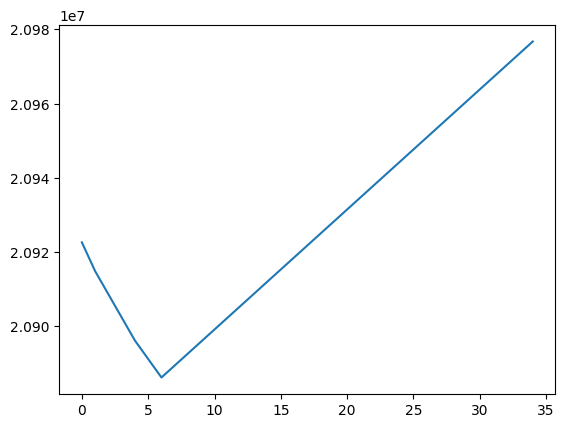

In [9]:
import seaborn as sns

alphas = [0.001, 0.01, 0.04, 1, 4, 6, 34]
mses = []
for a in alphas:
  lasso_model = Lasso(alpha=a)
  lasso_model.fit(X_train, y_train)

  y_pred = lasso_model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  print(f"Mean Squared Error for {a}: {mse}")
  mses.append(mse)

sns.lineplot(x=alphas, y=mses, markers="o")

LassoCV regression model

In [20]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score


alphas = [0.001, 0.01, 0.04, 1, 2, 3, 4, 6, 5, 58, 23, 100]
lasso_cv_model = LassoCV(alphas=alphas, cv=5, max_iter=1000, random_state=23)

lasso_cv_model.fit(X_train, y_train)

print("best alpha:", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("r2 score:", r2)

best alpha: 0.001
Mean Squared Error: 20922599.87103596
r2 score: 0.8652317499151699


RidgeCV regression model

In [23]:
from sklearn.linear_model import RidgeCV

alphas = [0.001, 0.01, 0.04, 1, 2, 3, 4, 6, 5, 58, 23, 100]
ridge_cv_model = RidgeCV(alphas=alphas, cv=5)

ridge_cv_model.fit(X_train, y_train)

print("best alpha:", ridge_cv_model.alpha_)

y_pred = ridge_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("r2 score:", r2)

best alpha: 0.01
Mean Squared Error: 20920713.858871628
r2 score: 0.8652438982409322


ElasticNet regression model

In [30]:
from sklearn.linear_model import ElasticNet

enet_cv_model = ElasticNet(alpha=0.01, l1_ratio=0.5,max_iter=1000, random_state=23)

enet_cv_model.fit(X_train, y_train)



y_pred = enet_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("r2 score:", r2)

Mean Squared Error: 20977471.761911385
r2 score: 0.864878304896018
